In [1]:
import os
import sys
import numpy as np
import pandas as pd
import nibabel as nib
import nilearn
from nilearn.image import resample_img
from nilearn import plotting
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from nilearn import masking
from natsort import natsorted

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedKFold, train_test_split
import matplotlib.pyplot as plt
from sklearn.model_selection import RepeatedStratifiedKFold

from tqdm import tqdm

Load MNI mask for cleaning betas

In [2]:
maskDir = 'F:\yujun\projects\data\masks'
maskFile = os.path.join(maskDir, 'MNI152_T1_2mm_brain_mask.nii.gz')
mask = nib.load(maskFile)

In [3]:
mask.get_fdata().shape

(91, 109, 91)

Resample MNI mask

In [5]:
temp_nii_path = r'F:\yujun\projects\AI_IAPS\GLM_singletrial/\betas\Sub3_1d/\beta_0001.nii'
temp_nii_data = nib.load(temp_nii_path)

In [6]:
# Resample the MNI mask to match the dimensions and voxel size of your NIfTI file
resampled_mask = resample_img(mask, target_affine=temp_nii_data.affine, target_shape=temp_nii_data.shape)

In [7]:
resampled_mask.shape

(79, 95, 79)

Load stimuli sequence

In [8]:
stim_dir = 'F:\yujun\projects\LAB_IAPS_AI\data\stimulus_v2'
stim_files = natsorted(os.listdir(stim_dir))
stim_files

['r1.txt',
 'r2.txt',
 'r3.txt',
 'r4.txt',
 'r5.txt',
 'r6.txt',
 'r7.txt',
 'r8.txt',
 'r9.txt',
 'r10.txt']

In [10]:
stimuli = []
for i, file in enumerate(stim_files):
    txt_path = os.path.join(stim_dir, file)
    data_array = np.loadtxt(txt_path, dtype=str)
    stimuli.append(data_array)
stimuli = np.array(stimuli).flatten()

Add stimuli types

In [11]:
stim_types = pd.read_csv('F:\yujun\projects\LAB_IAPS_AI\data\iaps_emotion_category_v2.csv')
stim_types

,id,iaps_id,img,emotion_type,AI,group
0,1205,1205,1205.jpg,unpleasant,NO,unpleasant
1,1205_2,1205,1205_2.jpg,unpleasant,YES,unpleasantAI
2,1270,1270,1270.jpg,unpleasant,NO,unpleasant
3,1270_0,1270,1270_0.jpg,unpleasant,YES,unpleasantAI
4,1419,1419,1419.jpg,neutral,NO,neutral
...,...,...,...,...,...,...
115,9900_2,9900,9900_2.jpg,unpleasant,YES,unpleasantAI
116,9905,9905,9905.jpg,unpleasant,NO,unpleasant
117,9905_2,9905,9905_2.jpg,unpleasant,YES,unpleasantAI
118,9909,9909,9909.jpg,unpleasant,NO,unpleasant


In [12]:
stimuli_df = pd.DataFrame({'Sequence': stimuli})
# Add an 'OriginalOrder' column to the df DataFrame
stimuli_df['OriginalOrder'] = stimuli_df.index
# Merge the two DataFrames based on the StimulusID column
merged_df = stimuli_df.merge(stim_types, left_on='Sequence', right_on='img')
# Sort the merged DataFrame based on the 'OriginalOrder' column
merged_df = merged_df.sort_values(by='OriginalOrder')
stimuli = merged_df[['OriginalOrder','img','emotion_type', 'AI', 'group']].reset_index(drop=True)
stimuli

,OriginalOrder,img,emotion_type,AI,group
0,0,2045_2.jpg,pleasant,YES,pleasantAI
1,1,6211_0.jpg,unpleasant,YES,unpleasantAI
2,2,5395_2.jpg,neutral,YES,neutralAI
3,3,3230_0.jpg,unpleasant,YES,unpleasantAI
4,4,2550.jpg,pleasant,NO,pleasant
...,...,...,...,...,...
595,595,3016_1.jpg,unpleasant,YES,unpleasantAI
596,596,9140.jpg,unpleasant,NO,unpleasant
597,597,2446.jpg,neutral,NO,neutral
598,598,9570_1.jpg,unpleasant,YES,unpleasantAI


Load Kastner mask

In [13]:
roi_labels = ['V1v',	    
 'V1d',	   
 'V2v',   
 'V2d',	   
 'V3v',	    
 'V3d',	    
 'hV4',	  
 'VO1',	    
 'VO2',	    
 'PHC1',	    
 'PHC2',	    
 'MST',	    
 'hMT',	   
 'LO2',	    
 'LO1',	   
 'V3b',	    
 'V3a',	  
 'IPS0',	   
 'IPS1',	    
 'IPS2',	    
 'IPS3',	  
 'IPS4',	  
 'IPS5',	  
 'SPL1',	 
 'FEF'	]

In [14]:
kastner_maxprob_l = nib.load(f'F:\yujun\projects\data\masks\ProbAtlas_v4\ProbAtlas_v4\subj_vol_all\\maxprob_vol_lh.nii.gz')
kastner_maxprob_r = nib.load(f'F:\yujun\projects\data\masks\ProbAtlas_v4\ProbAtlas_v4\subj_vol_all\\maxprob_vol_rh.nii.gz')   
kastner_maxprob_combine = kastner_maxprob_l.get_fdata() + kastner_maxprob_r.get_fdata()
kastner_kastner_maxprob_combine_nii = nib.Nifti1Image(kastner_maxprob_combine, kastner_maxprob_r.affine)
kastner_maxprob_resample = resample_img(kastner_kastner_maxprob_combine_nii, target_affine=temp_nii_data.affine, target_shape=temp_nii_data.shape)
# Round the values to the nearest integer to preserve ROI labels
rounded_data = np.round(kastner_maxprob_resample.get_fdata())
print("Original: " , kastner_maxprob_combine.shape, '\n', "Resampled: ", kastner_maxprob_resample.get_fdata().shape)

Original:  (182, 218, 182) 
 Resampled:  (79, 95, 79)


In [15]:
# Separate each ROI into its own mask and save to a dictionary
roi_masks = {}
for roi_label in range(1, 26):  # Assuming ROI labels are 1 through 25
    roi_mask_data = (rounded_data == roi_label).astype(int)
    roi_mask_img = nib.Nifti1Image(roi_mask_data, affine=temp_nii_data.affine)
    
    # Example of saving the mask; adjust filenames as needed
    roi_name = roi_labels[roi_label-1]
    # nib.save(roi_mask_img, f'{roi_name}.nii.gz')
    
    # Store in dictionary
    roi_masks[roi_name] = roi_mask_img

for (k, v) in roi_masks.items():
    print(k, v.get_fdata().shape, np.count_nonzero(v.get_fdata()))

V1v (79, 95, 79) 856
V1d (79, 95, 79) 748
V2v (79, 95, 79) 727
V2d (79, 95, 79) 645
V3v (79, 95, 79) 527
V3d (79, 95, 79) 517
hV4 (79, 95, 79) 328
VO1 (79, 95, 79) 153
VO2 (79, 95, 79) 253
PHC1 (79, 95, 79) 175
PHC2 (79, 95, 79) 165
MST (79, 95, 79) 3
hMT (79, 95, 79) 86
LO2 (79, 95, 79) 125
LO1 (79, 95, 79) 324
V3b (79, 95, 79) 263
V3a (79, 95, 79) 554
IPS0 (79, 95, 79) 499
IPS1 (79, 95, 79) 248
IPS2 (79, 95, 79) 113
IPS3 (79, 95, 79) 86
IPS4 (79, 95, 79) 21
IPS5 (79, 95, 79) 6
SPL1 (79, 95, 79) 11
FEF (79, 95, 79) 7


#### Load AAL3 mask

In [28]:
aal3_label = [
#  'ACCpre',
#  'ACCsub',
#  'ACCsup',
 'Amygdala',
#  'Angular',
#  'Calcarine',
#  'Caudate',
#  'CingulateAnt',
#  'CingulateMid',
#  'CingulatePost',
 'Cuneus',
 'Fusiform',
 'Hippocampus',
 'Insula',
#  'Lingual',
 'ParaHippocampal',
 'Postcentral',
 'Precentral',
 'Precuneus'
#  'Putamen',
#  'ThalPuL'
]

In [29]:
aal3_bins = []
aal3_masks = []

for i in range(len(aal3_label)):
    aal3_nii = nib.load(f'F:\yujun\projects\data\masks\AAL3\\new\{aal3_label[i]}.nii.gz')
    aal3_resample = resample_img(aal3_nii, target_affine=temp_nii_data.affine, target_shape=temp_nii_data.shape)
    aal3_bin = np.where(aal3_resample.get_fdata() > 0, 1, 0)
    aal3_masks.append(nib.Nifti1Image(aal3_bin, temp_nii_data.affine))
    aal3_bins.append(aal3_bin)

In [30]:
print(f"original size: {aal3_nii.get_fdata().shape}")
print(f"resampled size: {aal3_bin.shape}")

original size: (91, 109, 91)
resampled size: (79, 95, 79)


In [1085]:
# roi = 'Amygdala'
# view = plotting.view_img(aal3_masks[aal3_label.index(roi)], title = f"{roi}")
# view

In [31]:
aal3_dict = dict(zip(aal3_label, aal3_bins))

In [32]:
kastner_dict.update(aal3_dict)

In [33]:
roi_dict = kastner_dict
len(roi_dict)

34

In [34]:
roi_dict.keys()

dict_keys(['V1v', 'V1d', 'V2v', 'V2d', 'V3v', 'V3d', 'hV4', 'VO1', 'VO2', 'PHC1', 'PHC2', 'MST', 'hMT', 'LO2', 'LO1', 'V3b', 'V3a', 'IPS0', 'IPS1', 'IPS2', 'IPS3', 'IPS4', 'IPS5', 'SPL1', 'FEF', 'Amygdala', 'Cuneus', 'Fusiform', 'Hippocampus', 'Insula', 'ParaHippocampal', 'Postcentral', 'Precentral', 'Precuneus'])

#### Define ROI mask

In [21]:
print(len(roi_masks))
for roi_name, roi_bin in roi_masks.items():
    print(f'There are {np.count_nonzero(roi_bin.get_fdata())} voxels in the ROI: {roi_name}')

25
There are 856 voxels in the ROI: V1v
There are 748 voxels in the ROI: V1d
There are 727 voxels in the ROI: V2v
There are 645 voxels in the ROI: V2d
There are 527 voxels in the ROI: V3v
There are 517 voxels in the ROI: V3d
There are 328 voxels in the ROI: hV4
There are 153 voxels in the ROI: VO1
There are 253 voxels in the ROI: VO2
There are 175 voxels in the ROI: PHC1
There are 165 voxels in the ROI: PHC2
There are 3 voxels in the ROI: MST
There are 86 voxels in the ROI: hMT
There are 125 voxels in the ROI: LO2
There are 324 voxels in the ROI: LO1
There are 263 voxels in the ROI: V3b
There are 554 voxels in the ROI: V3a
There are 499 voxels in the ROI: IPS0
There are 248 voxels in the ROI: IPS1
There are 113 voxels in the ROI: IPS2
There are 86 voxels in the ROI: IPS3
There are 21 voxels in the ROI: IPS4
There are 6 voxels in the ROI: IPS5
There are 11 voxels in the ROI: SPL1
There are 7 voxels in the ROI: FEF


#### Load beta series and apply mask

In [147]:
# beta_series = np.load(r'F:\yujun\projects\AI_IAPS\GLM_singletrial/\betas\Sub3/delay_beta_series_4405xxxx27.npy')
# beta_series.shape

(600, 79, 95, 79)

In [22]:
beta_idx = []
for i in range(0 ,10): # runs
    id = [(x + 66*i) for x in range(1,61)]
    beta_idx.append(id)
beta_id = np.array(beta_idx).reshape(1, -1)

In [30]:
dataDir = '../GLM_singletrial/betas/'
subs = os.listdir(dataDir[:])
subs = list([subs[-1]])
subs

['Sub3_1d']

In [32]:
beta_series = []
z_series = []

for sub in subs:
    sub_dir = os.path.join(dataDir, sub)
    filenames = os.listdir(sub_dir)
    # Extract the IDs from the filenames
    file_ids = [int(os.path.splitext(filename)[0].split('_')[1]) for filename in filenames if os.path.splitext(filename)[0].split('_')[0] == 'beta']
    # Filter the filenames based on the ID list
    selected_filenames = [filename for filename, file_id in zip(filenames, file_ids) if file_id in beta_id]
    print(f'Number of betas for the subject: {len(selected_filenames)}')
    
    beta_arrays = []
    sub_z_series = []
    for i in range(len(selected_filenames)):
        # Load the NIfTI file
        file_path = os.path.join(dataDir, sub, selected_filenames[i])
        nii_data = nib.load(file_path)
        # Apply the mask to the NIfTI image
        masked_data = masking.apply_mask(nii_data, resampled_mask)
        # Get the mask's indices in the original 3D shape
        mask_indices = np.where(resampled_mask.get_fdata())
        # Create a new 3D array filled with zeros
        reshaped_data = np.empty(nii_data.shape)
        reshaped_data[:] = np.nan
        # Fill the new 3D array with the values from the masked data
        reshaped_data[mask_indices] = masked_data
        beta_arrays.append(reshaped_data)

    sub_beta_arrays = np.array(beta_arrays)
    beta_series.append(sub_beta_arrays)
    # z-score standardization
    # Calculate the mean and standard deviation along axis 0
    mean = sub_beta_arrays.mean(axis=0)
    std = sub_beta_arrays.std(axis=0)
    # Perform z-score standardization along axis 0
    sub_z_series = (sub_beta_arrays - mean) / std
    z_series.append(sub_z_series)


Number of betas for the subject: 244


C:\Users\yujunchen\AppData\Local\Temp\ipykernel_24488\3557953786.py:37: RuntimeWarning: invalid value encountered in true_divide
  sub_z_series = (sub_beta_arrays - mean) / std


Define decode id by runs

In [43]:
runs = [1, 2, 3, 4]
decode_ids = []
decode_names = []

for i, run in enumerate(runs):

    
    # Conditions involving 'stimuli' DataFrame
    # condition1 = (stimuli['emotion_type'].isin(['pleasant', 'neutral'])) & (stimuli['OriginalOrder'].between(60*(run-1), 60*run-1, inclusive=True))
    # condition2 = (stimuli['emotion_type'].isin(['pleasant', 'unpleasant'])) & (stimuli['OriginalOrder'].between(60*(run-1), 60*run-1, inclusive=True))
    # condition3 = (stimuli['emotion_type'].isin(['unpleasant', 'neutral'])) & (stimuli['OriginalOrder'].between(60*(run-1), 60*run-1, inclusive=True))
    condition4 = (stimuli['emotion_type'].isin(['pleasant', 'neutral']) & (stimuli['AI'] == 'NO')) & (stimuli['OriginalOrder'].between(60*(run-1), 60*run-1, inclusive=True))
    condition5 = (stimuli['emotion_type'].isin(['pleasant', 'unpleasant']) & (stimuli['AI'] == 'NO')) & (stimuli['OriginalOrder'].between(60*(run-1), 60*run-1, inclusive=True))
    condition6 = (stimuli['emotion_type'].isin(['unpleasant', 'neutral']) & (stimuli['AI'] == 'NO')) & (stimuli['OriginalOrder'].between(60*(run-1), 60*run-1, inclusive=True))
    condition7 = (stimuli['emotion_type'].isin(['pleasant', 'neutral']) & (stimuli['AI'] == 'YES')) & (stimuli['OriginalOrder'].between(60*(run-1), 60*run-1, inclusive=True))
    condition8 = (stimuli['emotion_type'].isin(['unpleasant', 'pleasant']) & (stimuli['AI'] == 'YES')) & (stimuli['OriginalOrder'].between(60*(run-1), 60*run-1, inclusive=True))
    condition9 = (stimuli['emotion_type'].isin(['unpleasant', 'neutral']) & (stimuli['AI'] == 'YES')) & (stimuli['OriginalOrder'].between(60*(run-1), 60*run-1, inclusive=True))
    # condition10 = (stimuli['emotion_type'] == 'pleasant') & (stimuli['OriginalOrder'].between(60*(run-1), 60*run-1, inclusive=True))
    # condition11 = (stimuli['emotion_type'] == 'neutral') & (stimuli['OriginalOrder'].between(60*(run-1), 60*run-1, inclusive=True))
    # condition12 = (stimuli['emotion_type'] == 'unpleasant') & (stimuli['OriginalOrder'].between(60*(run-1), 60*run-1, inclusive=True))

    # Append based on conditions
    # decode_ids.append(np.where(condition1)[0])
    # decode_names.append('Decode pleasant vs. neutral images.')

    # decode_ids.append(np.where(condition2)[0])
    # decode_names.append('Decode pleasant vs. unpleasant images.')

    # decode_ids.append(np.where(condition3)[0])
    # decode_names.append('Decode unpleasant vs. neutral images.')

    decode_ids.append(np.where(condition4)[0])
    decode_names.append('Decode pleasant vs. neutral (natural) images.')

    decode_ids.append(np.where(condition5)[0])
    decode_names.append('Decode pleasant vs. unpleasant (natural) images.')

    decode_ids.append(np.where(condition6)[0])
    decode_names.append('Decode unpleasant vs. neutral (natural) images.')

    decode_ids.append(np.where(condition7)[0])
    decode_names.append('Decode pleasant vs. neutral (AI) images.')

    decode_ids.append(np.where(condition8)[0])
    decode_names.append('Decode pleasant vs. unpleasant (AI) images.')

    decode_ids.append(np.where(condition9)[0])
    decode_names.append('Decode unpleasant vs. neutral (AI) images.')

    # decode_ids.append(np.where(condition10)[0])
    # decode_names.append('Decode AI vs. natural (pleasant) images.')

    # decode_ids.append(np.where(condition11)[0])
    # decode_names.append('Decode AI vs. natural (neutral) images.')

    # decode_ids.append(np.where(condition12)[0])
    # decode_names.append('Decode AI vs. natural (unpleasant) images.')



decode_dict = dict(zip(decode_names, decode_ids))

C:\Users\yujunchen\AppData\Local\Temp\ipykernel_24488\3614360348.py:12: FutureWarning: Boolean inputs to the `inclusive` argument are deprecated in favour of `both` or `neither`.
  condition4 = (stimuli['emotion_type'].isin(['pleasant', 'neutral']) & (stimuli['AI'] == 'NO')) & (stimuli['OriginalOrder'].between(60*(run-1), 60*run-1, inclusive=True))
C:\Users\yujunchen\AppData\Local\Temp\ipykernel_24488\3614360348.py:13: FutureWarning: Boolean inputs to the `inclusive` argument are deprecated in favour of `both` or `neither`.
  condition5 = (stimuli['emotion_type'].isin(['pleasant', 'unpleasant']) & (stimuli['AI'] == 'NO')) & (stimuli['OriginalOrder'].between(60*(run-1), 60*run-1, inclusive=True))
C:\Users\yujunchen\AppData\Local\Temp\ipykernel_24488\3614360348.py:14: FutureWarning: Boolean inputs to the `inclusive` argument are deprecated in favour of `both` or `neither`.
  condition6 = (stimuli['emotion_type'].isin(['unpleasant', 'neutral']) & (stimuli['AI'] == 'NO')) & (stimuli['Origi

In [34]:
# select_decode_ids = np.transpose(np.array(select_decode_ids))
# np.vstack(select_decode_ids[2]).reshape(1, -1)

C:\Users\yujunchen\AppData\Local\Temp\ipykernel_24488\2372094858.py:1: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  select_decode_ids = np.transpose(np.array(select_decode_ids))


array([[  1,   2,   3,   5,   6,   7,  10,  11,  12,  13,  14,  15,  16,
         17,  20,  21,  22,  23,  24,  28,  29,  31,  32,  33,  34,  37,
         38,  40,  44,  45,  48,  49,  50,  51,  52,  53,  55,  57,  58,
         59,  60,  62,  64,  65,  66,  67,  68,  69,  70,  72,  73,  75,
         76,  77,  78,  80,  81,  82,  83,  84,  86,  88,  89,  91,  92,
         94,  95,  96, 100, 103, 104, 105, 106, 107, 109, 110, 111, 112,
        114, 118, 120, 121, 122, 123, 127, 128, 129, 130, 131, 132, 133,
        134, 135, 136, 137, 140, 143, 144, 146, 147, 148, 149, 150, 152,
        153, 154, 156, 159, 161, 162, 163, 164, 166, 167, 168, 169, 171,
        173, 175, 178, 180, 181, 182, 183, 187, 188, 189, 190, 192, 193,
        194, 195, 196, 198, 199, 200, 201, 205, 209, 210, 212, 216, 218,
        219, 220, 221, 223, 224, 226, 227, 228, 229, 230, 231, 232, 234,
        235, 237, 238, 239]], dtype=int64)

In [35]:
# select_decode_ids[0]

array([array([ 0,  2,  4,  5,  6,  8,  9, 10, 13, 14, 15, 16, 18, 19, 23, 24, 25,
              26, 27, 29, 30, 31, 32, 33, 35, 36, 37, 39, 41, 42, 43, 46, 47, 48,
              49, 50, 51, 54, 55, 56], dtype=int64)                              ,
       array([ 61,  62,  63,  64,  65,  66,  67,  70,  71,  72,  73,  74,  75,
               79,  80,  83,  85,  86,  87,  88,  90,  93,  96,  97,  98,  99,
              100, 101, 102, 106, 108, 109, 110, 112, 113, 115, 116, 117, 118,
              119], dtype=int64)                                              ,
       array([121, 122, 123, 124, 125, 126, 129, 130, 132, 136, 138, 139, 140,
              141, 142, 144, 145, 146, 151, 154, 155, 157, 158, 159, 160, 162,
              163, 164, 165, 166, 168, 170, 171, 172, 174, 175, 176, 177, 178,
              179], dtype=int64)                                              ,
       array([181, 184, 185, 186, 188, 190, 191, 193, 194, 197, 201, 202, 203,
              204, 206, 207, 208, 209, 2

In [44]:
len(decode_dict)

6

SVM

In [36]:
beta_series_arr = np.array(beta_series)
beta_series_arr.shape

(1, 244, 79, 95, 79)

In [37]:
z_series_arr = np.array(z_series)
z_series_arr.shape

(1, 244, 79, 95, 79)

In [45]:
beta_arr = beta_series_arr.reshape(beta_series_arr.shape[0], beta_series_arr.shape[1], -1)
beta_arr.shape

(1, 244, 592895)

In [46]:
z_arr = z_series_arr.reshape(z_series_arr.shape[0], z_series_arr.shape[1], -1)
z_arr.shape

(1, 244, 592895)

In [39]:
test_roi_dict = {k: v for k, v in list(roi_masks.items())[:17]}
len(test_roi_dict)

17

In [47]:
# Stratified 10-fold cross-validation
rskf  = RepeatedStratifiedKFold(n_splits=10, n_repeats=10, random_state=42)

rois = []

for m , (roi_name, roi_mask) in tqdm(enumerate(test_roi_dict.items())):
    flat_roi_data = roi_mask.get_fdata()
    # roi_flat = flat_roi_data.flatten(order='F') # this is the same as reshape(1, -1)
    roi_flat = flat_roi_data.flatten()
    indices = np.where(roi_flat)[0]
    roi_betas = z_arr[:, :, indices]

    # print(f'Now decoding {roi_name}')
    cases = []
    for i, (decode_name, decode_id) in enumerate(decode_dict.items()):
       
        subjects = []
        for s in range(len(subs)):
            betas = roi_betas[s, decode_id, :]
            betas_mean = np.mean(betas, axis=0)
            betas_std = np.std(betas, axis=0)
            betas_z = (betas - betas_mean) / betas_std

            nan_columns = np.any(np.isnan(betas), axis=0)
            data = betas[:, ~nan_columns]

            labels = stimuli['emotion_type'][decode_id].reset_index(drop=True)

            sub_svc_scores = []
            for train_index, test_index in rskf.split(data, labels):
                X_train, X_test = data[train_index], data[test_index]
                y_train, y_test = labels[train_index], labels[test_index]

                # Create SVC classifiers with different kernels
                linear_svc = SVC(kernel='linear', random_state=42)

                # Fit the model
                linear_svc.fit(X_train, y_train)

                # Evaluate the model
                linear_score = linear_svc.score(X_test, y_test)
                sub_svc_scores.append(linear_score)

            avgsub_svc_scores = np.mean(sub_svc_scores)
            subjects.append(avgsub_svc_scores)
        # print(f"{decode_names[i]} Trial count: {len(decode_ids[i])}")
        # print("Average Linear SVC accuracy:", avg_linear_score)
        # print("------------------")
        cases.append(subjects)

    # print('=============================================')
    rois.append(cases)

17it [00:34,  2.01s/it]


In [48]:
np.save('./outputs/Sub3_17roi_2runs.npy', rois)

In [1033]:
# decode_names = []
# decode_names.append('pleasant vs. neutral')
# decode_names.append('pleasant vs. unpleasant')
# decode_names.append('unpleasant vs. neutral')
# decode_names.append('pleasant vs. neutral (natrual)')
# decode_names.append('pleasant vs. unpleasant (natrual)')
# decode_names.append('unpleasant vs. neutral (natrual)')
# decode_names.append('pleasant vs. neutral (AI)')
# decode_names.append('pleasant vs. unpleasant (AI)')
# decode_names.append('unpleasant vs. neutral (AI)')
# decode_names.append('AI vs. natrual (pleasant)')
# decode_names.append('AI vs. natrual (neutral)')
# decode_names.append('AI vs. natrual (unpleasant)')

2 full runs

In [174]:
decode_names2 = []
decode_names2.append('pleasant vs. neutral')
decode_names2.append('pleasant vs. unpleasant')
decode_names2.append('unpleasant vs. neutral')
decode_names2.append('pleasant vs. neutral (natrual)')
decode_names2.append('pleasant vs. unpleasant (natrual)')
decode_names2.append('unpleasant vs. neutral (natrual)')
decode_names2.append('pleasant vs. neutral (AI)')
decode_names2.append('pleasant vs. unpleasant (AI)')
decode_names2.append('unpleasant vs. neutral (AI)')
decode_names2.append('AI vs. natrual (pleasant)')
decode_names2.append('AI vs. natrual (neutral)')
decode_names2.append('AI vs. natrual (unpleasant)')

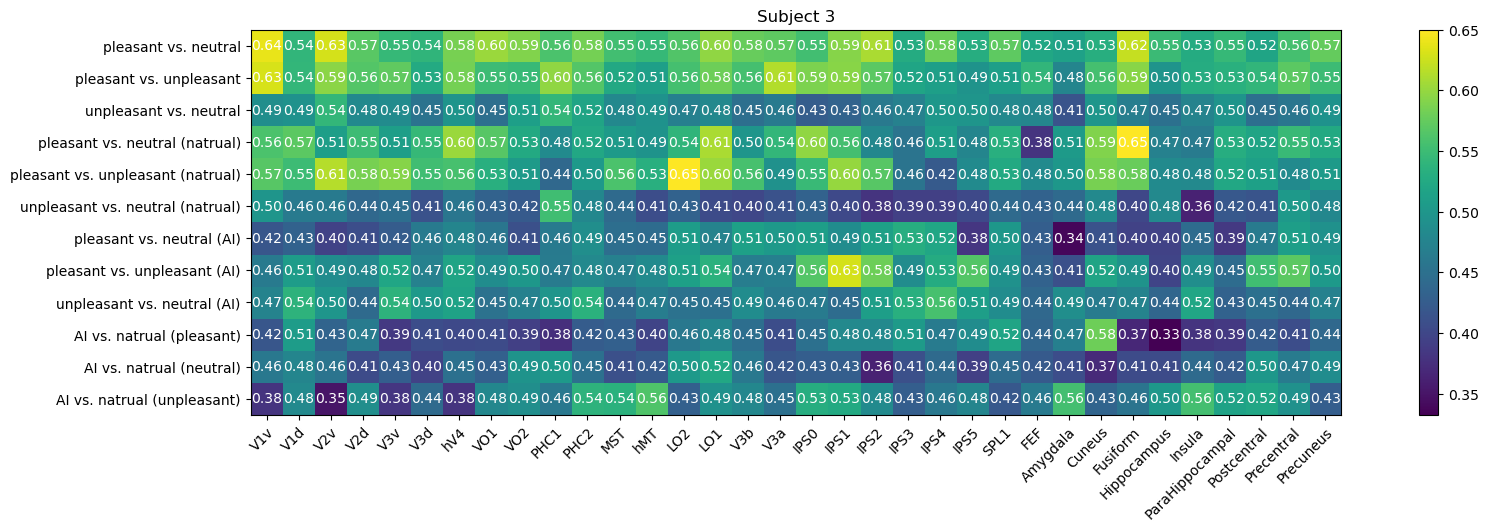

In [175]:
from mlxtend.plotting import heatmap
heatmap(np.array(rois).T, column_names = roi_names, row_names = decode_names2, figsize=(20, 5))
plt.title("Subject 3")
plt.show()

In [177]:
deselect_roi_id = [42,41,31,30,29, 25, 26, 27, -7]

In [183]:
rois_all = []
rois_all.append(np.delete(np.load('./outputs/Sub1_43roi.npy'), deselect_roi_id,axis=0))
rois_all.append(np.delete(np.load('./outputs/Sub2_43roi.npy'), deselect_roi_id,axis=0))
rois_all.append(np.load('./outputs/Sub3_34roi_2runs.npy'))

In [184]:
rois_all[2].shape

(34, 12)

In [185]:
rois_all = np.array(rois_all)
rois_avg = np.average(rois_all, axis=0)

Plotting

subject 1

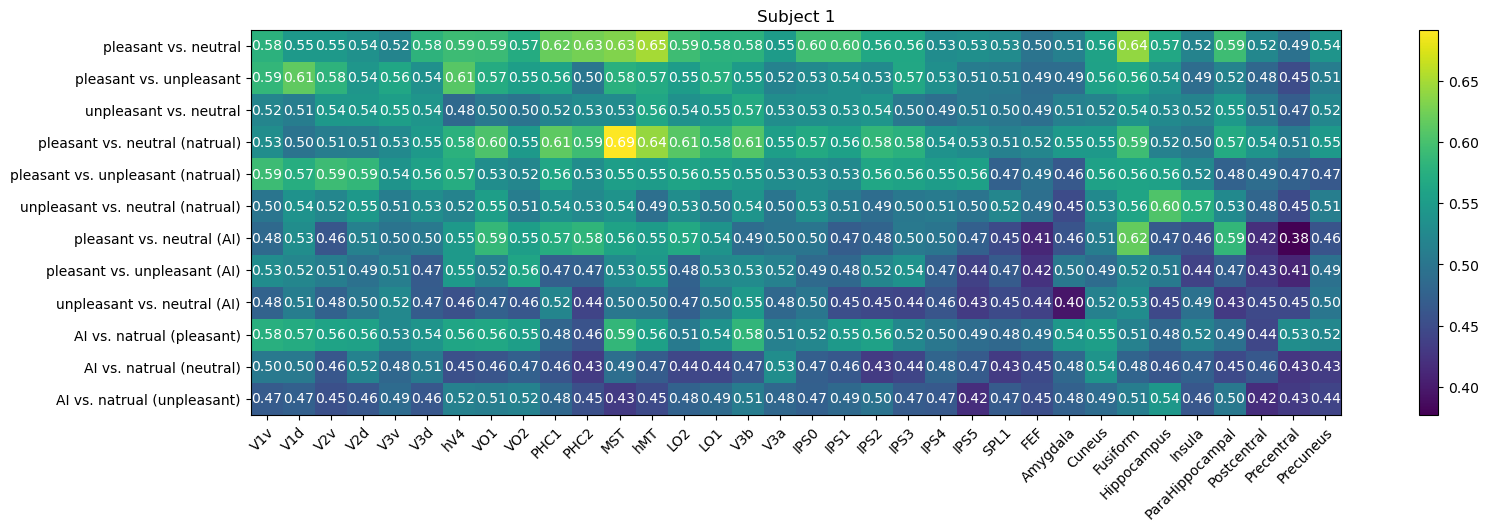

In [172]:
from mlxtend.plotting import heatmap
heatmap(rois_all[0].T, column_names = roi_names, row_names = decode_names2, figsize=(20, 5))
plt.title("Subject 1")
plt.show()

subject 2

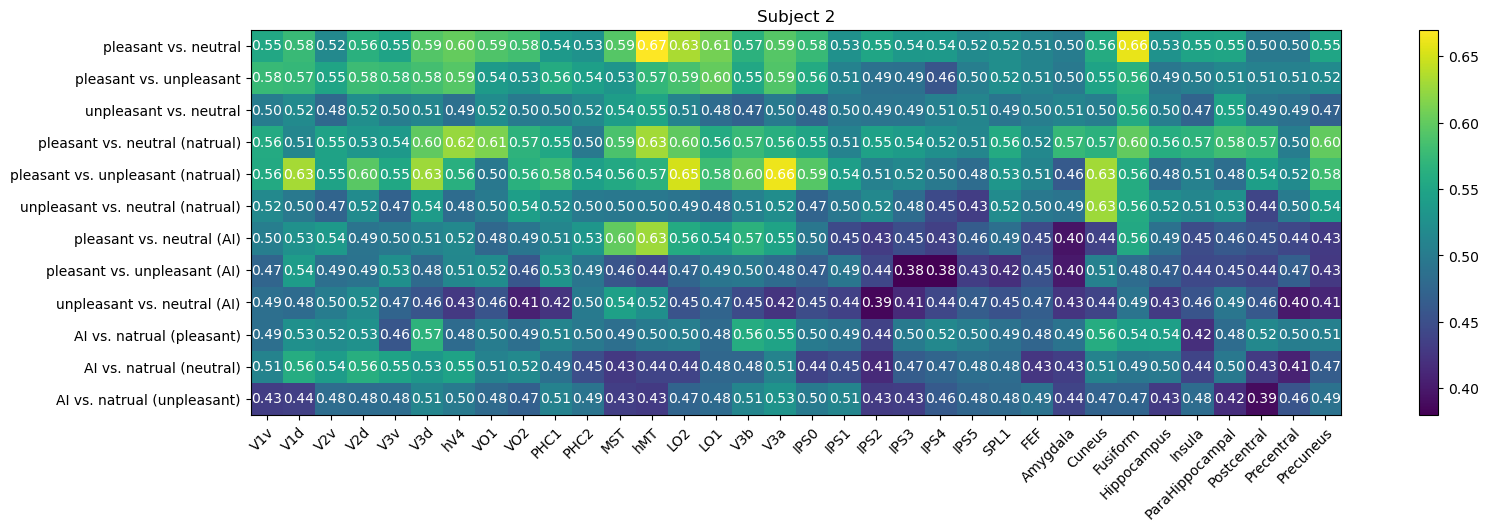

In [173]:
from mlxtend.plotting import heatmap
heatmap(rois_all[1].T, column_names = roi_names, row_names = decode_names2, figsize=(20, 5))
plt.title("Subject 2")
plt.show()

avg

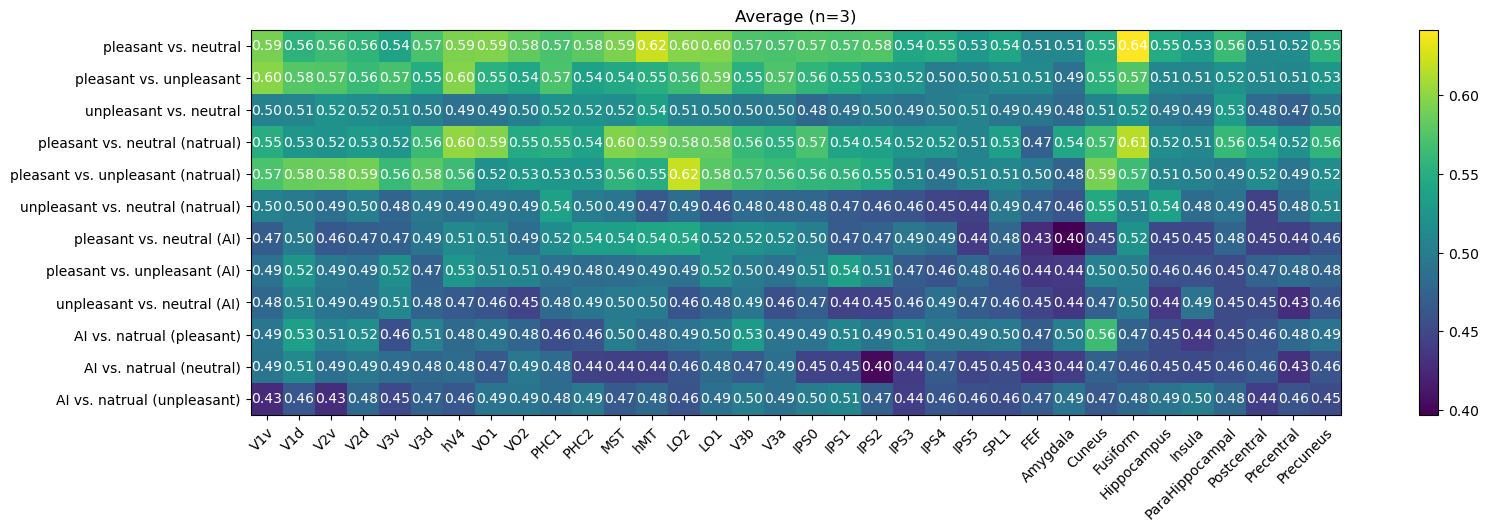

In [188]:
from mlxtend.plotting import heatmap
heatmap(np.array(rois_avg).T, column_names = roi_names, row_names = decode_names2, figsize=(20, 5))
plt.title("Average (n=3)")
plt.show()

Cross-Decoding

In [208]:
xdecode_ids = []
xdecode_names = []

xdecode_ids.append(np.where(((stimuli['emotion_type'] == 'pleasant') | (stimuli['emotion_type'] == 'neutral')) & (stimuli['AI'] == 'NO'))[0])
xdecode_ids.append(np.where(((stimuli['emotion_type'] == 'pleasant') | (stimuli['emotion_type'] == 'unpleasant')) & (stimuli['AI'] == 'NO'))[0])
xdecode_ids.append(np.where(((stimuli['emotion_type'] == 'unpleasant') | (stimuli['emotion_type'] == 'neutral')) & (stimuli['AI'] == 'NO'))[0])
xdecode_ids.append(np.where(((stimuli['emotion_type'] == 'pleasant') | (stimuli['emotion_type'] == 'neutral')) & (stimuli['AI'] == 'YES'))[0])
xdecode_ids.append(np.where(((stimuli['emotion_type'] == 'pleasant') | (stimuli['emotion_type'] == 'unpleasant')) & (stimuli['AI'] == 'YES'))[0])
xdecode_ids.append(np.where(((stimuli['emotion_type'] == 'unpleasant') | (stimuli['emotion_type'] == 'neutral')) & (stimuli['AI'] == 'YES'))[0])

xdecode_names.append('AI (pleasant vs. neutral)')
xdecode_names.append('AI (pleasant vs. unpleasant)')
xdecode_names.append('AI (unpleasant vs. neutral)')
xdecode_names.append('natrual (pleasant vs. neutral)')
xdecode_names.append('natrual (pleasant vs. unpleasant)')
xdecode_names.append('natrual (unpleasant vs. neutral)')

In [209]:
len(xdecode_ids)

6

In [210]:
xdecode_ids[0]

array([  4,   6,  15,  16,  18,  19,  24,  26,  30,  31,  32,  37,  39,
        41,  43,  47,  48,  51,  55,  56,  61,  62,  64,  65,  67,  71,
        72,  73,  74,  80,  93,  99, 100, 102, 108, 109, 110, 113, 116,
       117, 122, 126, 129, 132, 136, 138, 141, 142, 146, 151, 157, 162,
       164, 168, 170, 171, 172, 174, 177, 178, 185, 186, 190, 194, 197,
       202, 206, 207, 208, 209, 210, 211, 215, 218, 220, 223, 227, 231,
       233, 239, 243, 249, 252, 254, 259, 262, 265, 267, 268, 270, 271,
       272, 273, 276, 277, 280, 281, 282, 290, 293, 301, 304, 308, 312,
       318, 319, 321, 323, 328, 335, 336, 338, 340, 342, 344, 346, 347,
       354, 356, 357, 361, 365, 367, 370, 372, 383, 384, 386, 394, 398,
       400, 401, 403, 404, 407, 409, 411, 412, 416, 419, 422, 423, 425,
       427, 428, 430, 431, 434, 435, 441, 445, 446, 448, 449, 454, 458,
       459, 462, 464, 469, 484, 487, 489, 491, 497, 500, 501, 503, 504,
       505, 507, 513, 514, 518, 519, 523, 529, 530, 534, 537, 54

In [214]:
runs = [1, 2, 3, 4]
select_xdecode_ids = []
select_xdecode_names = []

for i, run in enumerate(runs):
    xdecode_ids = []
    xdecode_names = []

    xdecode_ids.append(np.where(((stimuli['emotion_type'].isin(['pleasant', 'neutral']))) & (stimuli['AI'] == 'NO') & (stimuli['OriginalOrder'].between(60*(run-1), 60*run-1, inclusive=True))))
    xdecode_ids.append(np.where(((stimuli['emotion_type'].isin(['pleasant', 'unpleasant']))) & (stimuli['AI'] == 'NO') & (stimuli['OriginalOrder'].between(60*(run-1), 60*run-1, inclusive=True))))
    xdecode_ids.append(np.where(((stimuli['emotion_type'].isin(['unpleasant', 'neutral']))) & (stimuli['AI'] == 'NO') & (stimuli['OriginalOrder'].between(60*(run-1), 60*run-1, inclusive=True))))
    xdecode_ids.append(np.where(((stimuli['emotion_type'].isin(['pleasant', 'neutral']))) & (stimuli['AI'] == 'YES') & (stimuli['OriginalOrder'].between(60*(run-1), 60*run-1, inclusive=True))))
    xdecode_ids.append(np.where(((stimuli['emotion_type'].isin(['pleasant', 'unpleasant']))) & (stimuli['AI'] == 'YES') & (stimuli['OriginalOrder'].between(60*(run-1), 60*run-1, inclusive=True))))
    xdecode_ids.append(np.where(((stimuli['emotion_type'].isin(['unpleasant', 'neutral']))) & (stimuli['AI'] == 'YES') & (stimuli['OriginalOrder'].between(60*(run-1), 60*run-1, inclusive=True))))
                       
    xdecode_names.append('AI (pleasant vs. neutral)')
    xdecode_names.append('AI (pleasant vs. unpleasant)')
    xdecode_names.append('AI (unpleasant vs. neutral)')
    xdecode_names.append('natrual (pleasant vs. neutral)')
    xdecode_names.append('natrual (pleasant vs. unpleasant)')
    xdecode_names.append('natrual (unpleasant vs. neutral)')

    select_xdecode_ids.append(xdecode_ids)
    select_xdecode_names.append(xdecode_names)

C:\Users\yujunchen\AppData\Local\Temp\ipykernel_21060\3174470783.py:9: FutureWarning: Boolean inputs to the `inclusive` argument are deprecated in favour of `both` or `neither`.
  xdecode_ids.append(np.where(((stimuli['emotion_type'].isin(['pleasant', 'neutral']))) & (stimuli['AI'] == 'NO') & (stimuli['OriginalOrder'].between(60*(run-1), 60*run-1, inclusive=True))))
C:\Users\yujunchen\AppData\Local\Temp\ipykernel_21060\3174470783.py:10: FutureWarning: Boolean inputs to the `inclusive` argument are deprecated in favour of `both` or `neither`.
  xdecode_ids.append(np.where(((stimuli['emotion_type'].isin(['pleasant', 'unpleasant']))) & (stimuli['AI'] == 'NO') & (stimuli['OriginalOrder'].between(60*(run-1), 60*run-1, inclusive=True))))
C:\Users\yujunchen\AppData\Local\Temp\ipykernel_21060\3174470783.py:11: FutureWarning: Boolean inputs to the `inclusive` argument are deprecated in favour of `both` or `neither`.
  xdecode_ids.append(np.where(((stimuli['emotion_type'].isin(['unpleasant', 'ne

In [215]:
select_xdecode_ids2 = list(np.squeeze(np.array(select_xdecode_ids)).transpose(1, 0, 2).reshape(6, 80))

In [216]:
select_xdecode_ids2[0].shape

(80,)

In [190]:
flat_betas.shape

(600, 592895)

In [191]:
roi_bin.shape

(79, 95, 79)

In [218]:
rois_xdecode = []
# Iterate through the values of roi_dict
for roi_name, roi_bin in tqdm(roi_dict.items()):
    flat_roi = roi_bin.ravel()
    roi_betas = flat_betas[:, flat_roi == 1]

    # print(f'Now decoding {roi_name}')

    cases = []
    for i, xdecode_id in enumerate(select_xdecode_ids2):
        data_train = roi_betas[xdecode_id, :]  # (600, number of roi voxels)
        label_train = stimuli['emotion_type'][xdecode_id].reset_index(drop=True)
        if i == 0:
            data_test = roi_betas[select_xdecode_ids2[3], :]
            label_test = stimuli['emotion_type'][select_xdecode_ids2[3]].reset_index(drop=True)
        elif i == 1:
            data_test = roi_betas[select_xdecode_ids2[4], :]
            label_test = stimuli['emotion_type'][select_xdecode_ids2[4]].reset_index(drop=True)
        elif i == 2:
            data_test = roi_betas[select_xdecode_ids2[5], :]
            label_test = stimuli['emotion_type'][select_xdecode_ids2[5]].reset_index(drop=True)
        elif i == 3:
            data_test = roi_betas[select_xdecode_ids2[0], :]
            label_test = stimuli['emotion_type'][select_xdecode_ids2[0]].reset_index(drop=True)
        elif i == 4:
            data_test = roi_betas[select_xdecode_ids2[1], :]
            label_test = stimuli['emotion_type'][select_xdecode_ids2[1]].reset_index(drop=True)
        else:
            data_test = roi_betas[select_xdecode_ids2[2], :]
            label_test = stimuli['emotion_type'][select_xdecode_ids2[2]].reset_index(drop=True)

        # Create SVC classifiers with different kernels
        linear_svc = SVC(kernel='linear')

        # Fit the model
        linear_svc.fit(data_train, label_train)

        # Evaluate the model
        linear_score = linear_svc.score(data_test, label_test)

        # print(f"{decode_names[i]} Trial count: {len(decode_ids[i])}")
        # print("Average Linear SVC accuracy:", avg_linear_score)
        # print("------------------")
        cases.append(linear_score)

    # print('=============================================')
    rois_xdecode.append(cases)

100%|██████████| 34/34 [00:06<00:00,  4.93it/s]


In [219]:
np.save('./outputs/Sub3_34roi_xdeco.npy', rois_xdecode)

Below is non-essential

In [220]:
# deselect_roi_names = ['ACCpre', 'ACCsub', 'ACCsup', 'Angular', 'Calcarine', 'Caudate', 'CingulateMid', 'CingulatePost', 'Putamen', 'ThalPuA', 'ThalPuM', 'ThalPuL', 'ThalPuI']
# deselect_roi_id = [list(roi_dict.keys()).index(item) for item in deselect_roi_names]
deselect_roi_id = [42,41,31,30,29, 25, 26, 27]

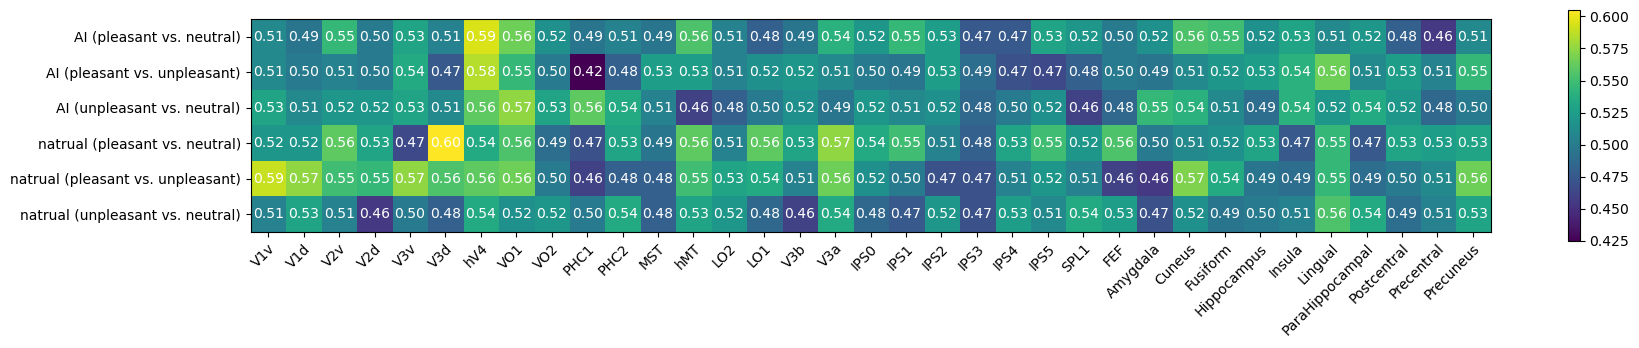

In [1141]:
from mlxtend.plotting import heatmap
heatmap(np.delete(np.array(rois_xdecode).T, deselect_roi_id,axis=1), column_names = [x for i, x in enumerate(roi_dict) if i not in deselect_roi_id], row_names = [x for i, x in enumerate(xdecode_names) if i not in deselect_roi_id], figsize=(20, 3))
plt.show()

In [1142]:
rois_all_xdeco = []
rois_all_xdeco.append(np.load('./outputs/Sub1_43ro_xdeco.npy'))
rois_all_xdeco.append(np.load('./outputs/Sub2_43ro_xdeco.npy'))
rois_all_xdeco.append(np.load('./outputs/Sub3_43roi_xdeco.npy'))

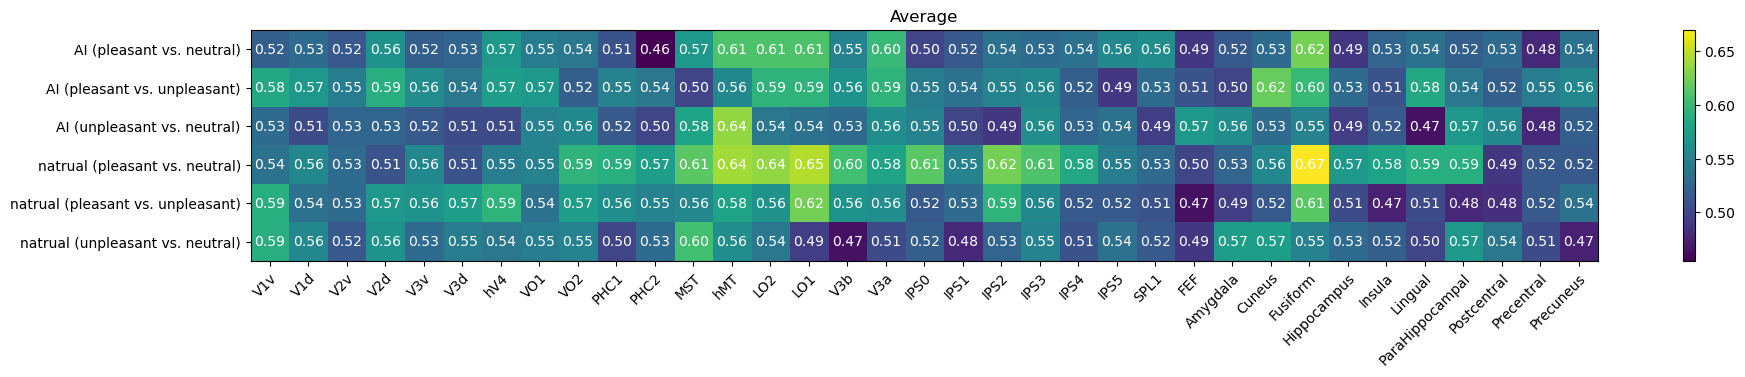

In [1152]:
heatmap(np.delete(np.array(rois_all_xdeco[1]).T, deselect_roi_id,axis=1), column_names = [x for i, x in enumerate(roi_names) if i not in deselect_roi_id], row_names = [x for i, x in enumerate(xdecode_names) if i not in deselect_roi_id], figsize=(22, 3))
plt.title("subject")
plt.show()

In [1143]:
rois_all_xdeco = np.array(rois_all_xdeco)
rois_avg_xdeco = np.average(rois_all_xdeco, axis=0)

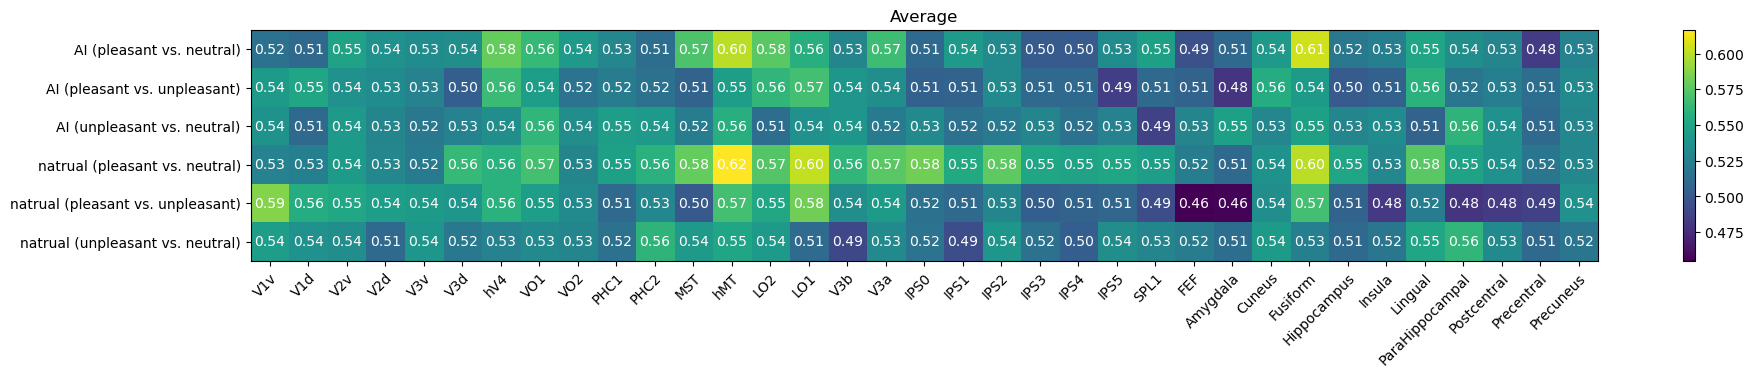

In [1144]:
heatmap(np.delete(np.array(rois_avg_xdeco).T, deselect_roi_id,axis=1), column_names = [x for i, x in enumerate(roi_names) if i not in deselect_roi_id], row_names = [x for i, x in enumerate(xdecode_names) if i not in deselect_roi_id], figsize=(22, 3))
plt.title("Average")
plt.show()

In [106]:
rois_avg_xdeco_arr = np.delete(np.array(rois_avg_xdeco).T, deselect_roi_id,axis=1)

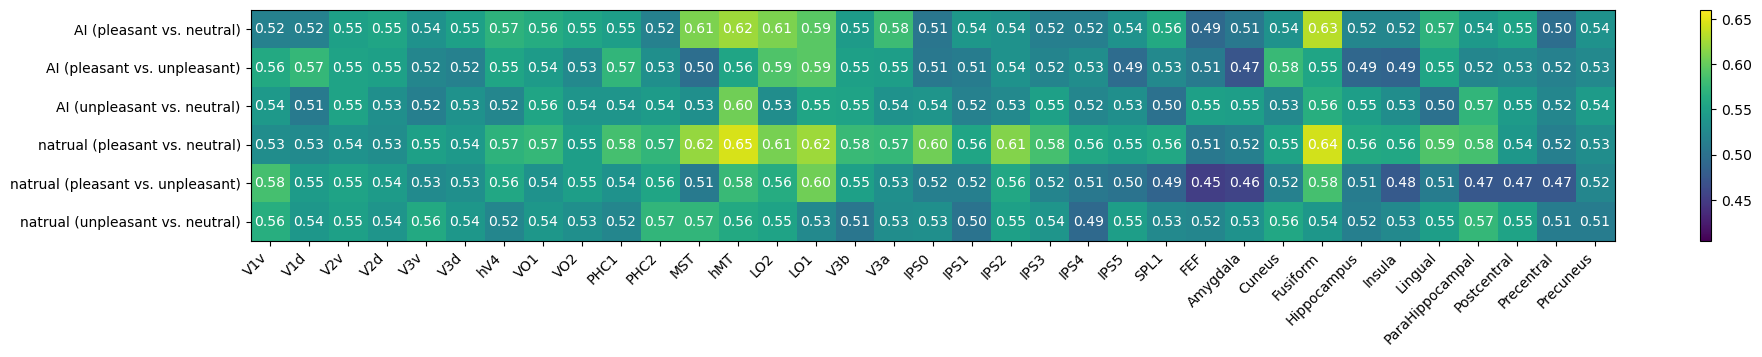

In [123]:
import matplotlib.pyplot as plt
import numpy as np

# Example heatmap data
heatmap_data = rois_avg_xdeco_arr

# Set the figure size
plt.figure(figsize=(22, 3))

# Create the heatmap
plt.imshow(heatmap_data, cmap='viridis', aspect='auto', vmin=0.405, vmax=0.66)

# Add value annotations to the cells
for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        plt.annotate(f'{heatmap_data[i, j]:.2f}', 
                     (j, i), 
                     ha='center', va='center', color='white')


cbar = plt.colorbar()

# Add custom x and y ticks
column_names = [x for i, x in enumerate(roi_names) if i not in deselect_roi_id]
row_names = [x for i, x in enumerate(xdecode_names) if i not in deselect_roi_id]
x_ticks = list(range((len(column_names))))
y_ticks = list(range((len(row_names))))
x_tick_labels = column_names # Replace with your desired x tick labels
y_tick_labels = row_names  # Replace with your desired y tick labels

plt.xticks(x_ticks, x_tick_labels, rotation = 45, ha='right')
plt.yticks(y_ticks, y_tick_labels)

# Add labels and title
# plt.xlabel('X-axis')
# plt.ylabel('Y-axis')
# plt.title('Avr')

# Show the plot
plt.show()

Decoding differences

In [128]:
rois_avg.shape

(43, 12)

In [129]:
rois_avg_xdeco.shape

(43, 6)

In [134]:
rois_avg_nat1 = rois_avg[:,0:3]
rois_avg_nat2 = rois_avg[:,3:6]
rois_avg_nat3 = rois_avg[:,6:9]
rois_avg_xdeco_nat = rois_avg_xdeco[:,0:3]

rois_avg_diif_nat1 = rois_avg_nat1-rois_avg_xdeco_nat
rois_avg_diif_nat2 = rois_avg_nat2-rois_avg_xdeco_nat
rois_avg_diif_nat3 = rois_avg_nat3-rois_avg_xdeco_nat
rois_avg_diif_nat = np.hstack((rois_avg_diif_nat1, rois_avg_diif_nat2, rois_avg_diif_nat3))

In [140]:

rois_avg_diif_nat.shape

(43, 9)

In [145]:
len(xdecode_names)

6

In [165]:
xdecode_diff_names = ['pl-nt,ALL dc-Nat. xdc',
    'pl-up,ALL dc-Nat. xdc',
    'up-nt,ALL dc-Nat. xdc',
    'pl-nt,Natural dc-Nat. xdc',
    'pl-up,Natural dc-Nat. xdc',
    'up-nt,Natural dc-Nat. xdc',
    'pl-nt,AI dc-Nat. xdc',
    'pl-up,AI dc-Nat. xdc',
    'up-nt,AI dc-Nat. xdc',
 ]

In [150]:
len(roi_names)

43

In [153]:
heatmap_data.shape

(9, 43)

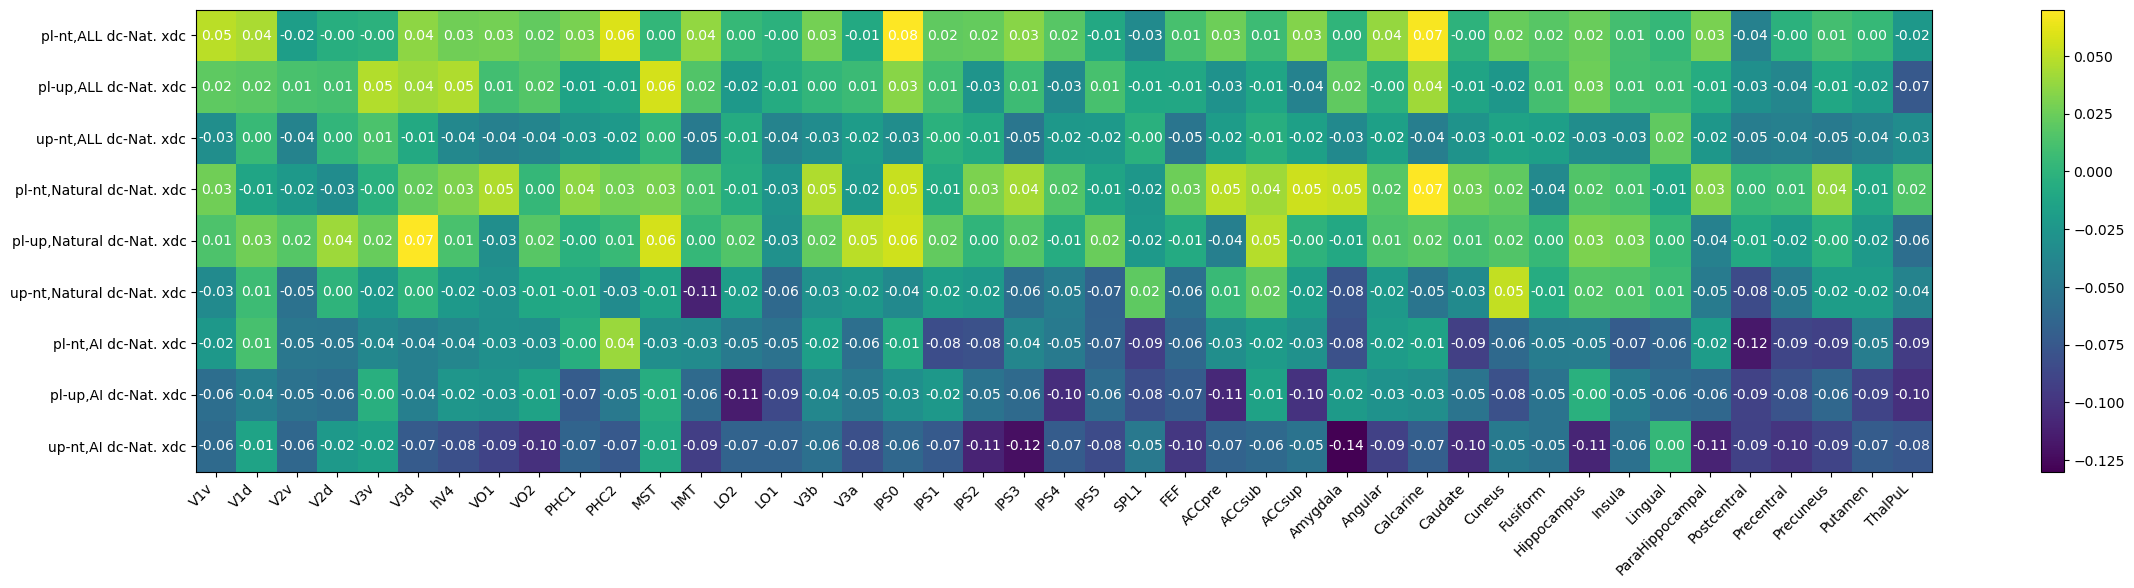

In [166]:
import matplotlib.pyplot as plt
import numpy as np

# Example heatmap data
heatmap_data = rois_avg_diif_nat.T

# Set the figure size
plt.figure(figsize=(28, 6))

# Create the heatmap
# plt.imshow(heatmap_data, cmap='viridis', aspect='auto', vmin=0.405, vmax=0.66)
plt.imshow(heatmap_data, cmap='viridis', aspect='auto',vmin=-0.13, vmax=0.07)

# Add value annotations to the cells
for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        plt.annotate(f'{heatmap_data[i, j]:.2f}', 
                     (j, i), 
                     ha='center', va='center', color='white')


cbar = plt.colorbar()

# Add custom x and y ticks
# column_names = [x for i, x in enumerate(roi_names) if i not in deselect_roi_id]
column_names = roi_names
row_names = xdecode_diff_names
x_ticks = list(range((len(column_names))))
y_ticks = list(range((len(row_names))))
x_tick_labels = column_names # Replace with your desired x tick labels
y_tick_labels = row_names  # Replace with your desired y tick labels

plt.xticks(x_ticks, x_tick_labels, rotation = 45, ha='right')
plt.yticks(y_ticks, y_tick_labels)

# Add labels and title
# plt.xlabel('X-axis')
# plt.ylabel('Y-axis')
# plt.title('Avr')

# Show the plot
plt.show()

- AI xdecode

In [157]:
rois_avg_xdeco.shape

(43, 6)

In [159]:
rois_avg_nat1 = rois_avg[:,0:3]
rois_avg_nat2 = rois_avg[:,3:6]
rois_avg_nat3 = rois_avg[:,6:9]
rois_avg_xdeco_ai = rois_avg_xdeco[:,3:6]

rois_avg_diif_ai1 = rois_avg_nat1-rois_avg_xdeco_ai
rois_avg_diif_ai2 = rois_avg_nat2-rois_avg_xdeco_ai
rois_avg_diif_ai3 = rois_avg_nat3-rois_avg_xdeco_ai
rois_avg_diif_ai = np.hstack((rois_avg_diif_ai1, rois_avg_diif_ai2, rois_avg_diif_ai3))

In [161]:
xdecode_diff_names = ['pl-nt,ALL dc-AI xdc',
    'pl-up,ALL dc-AI xdc',
    'up-nt,ALL dc-AI xdc',
    'pl-nt,Natural dc-AI xdc',
    'pl-up,Natural dc-AI. xdc',
    'up-nt,Natural dc-AI. xdc',
    'pl-nt,AI dc-AI xdc',
    'pl-up,AI dc-AI xdc',
    'up-nt,AI dc-AI xdc',
 ]

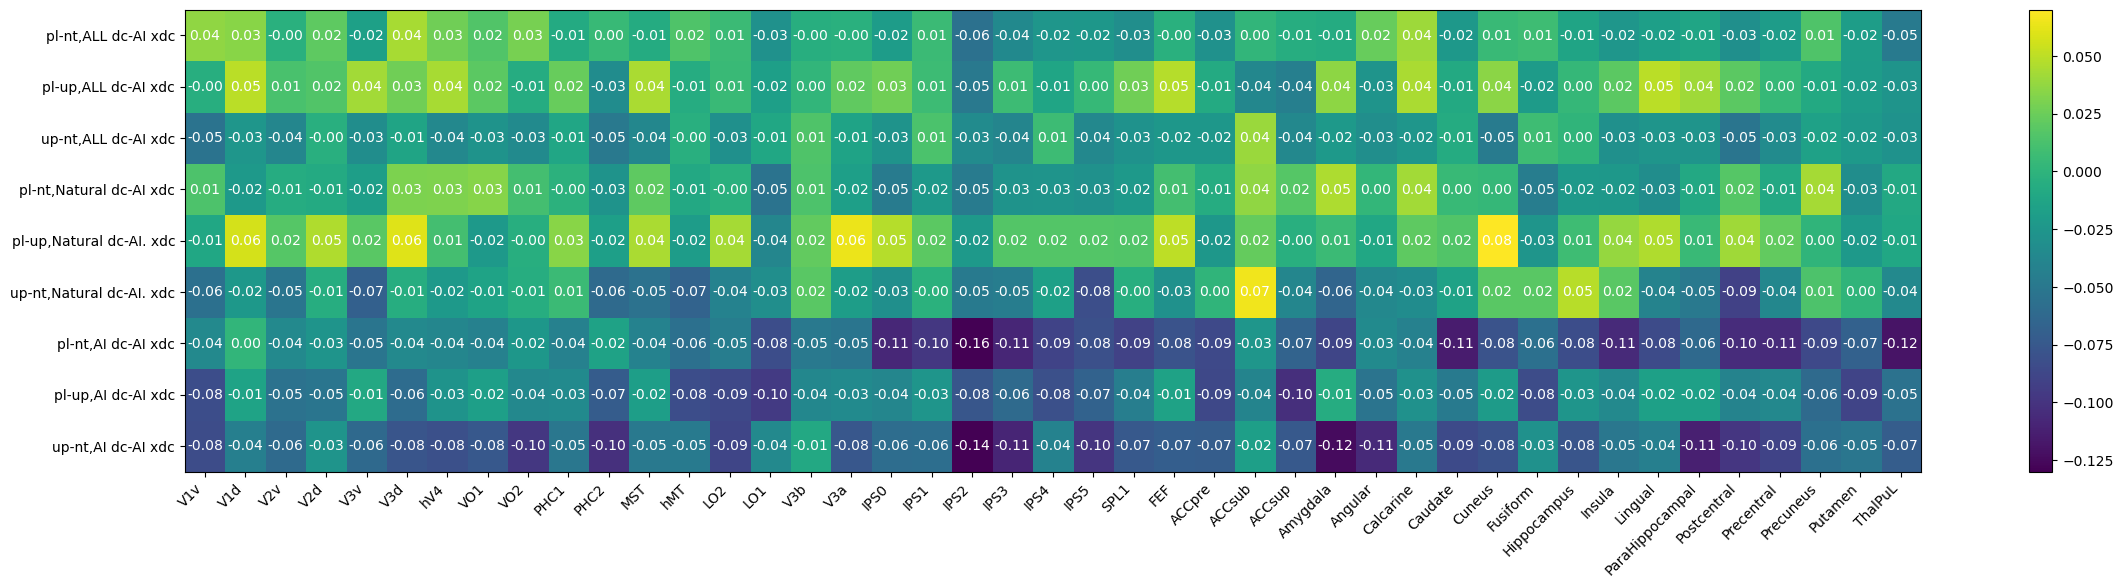

In [164]:
import matplotlib.pyplot as plt
import numpy as np

# Example heatmap data
heatmap_data = rois_avg_diif_ai.T

# Set the figure size
plt.figure(figsize=(28, 6))

# Create the heatmap
# plt.imshow(heatmap_data, cmap='viridis', aspect='auto', vmin=0.405, vmax=0.66)
plt.imshow(heatmap_data, cmap='viridis', aspect='auto', vmin=-0.13, vmax=0.07)

# Add value annotations to the cells
for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        plt.annotate(f'{heatmap_data[i, j]:.2f}', 
                     (j, i), 
                     ha='center', va='center', color='white')


cbar = plt.colorbar()

# Add custom x and y ticks
# column_names = [x for i, x in enumerate(roi_names) if i not in deselect_roi_id]
column_names = roi_names
row_names = xdecode_diff_names
x_ticks = list(range((len(column_names))))
y_ticks = list(range((len(row_names))))
x_tick_labels = column_names # Replace with your desired x tick labels
y_tick_labels = row_names  # Replace with your desired y tick labels

plt.xticks(x_ticks, x_tick_labels, rotation = 45, ha='right')
plt.yticks(y_ticks, y_tick_labels)

# Add labels and title
# plt.xlabel('X-axis')
# plt.ylabel('Y-axis')
# plt.title('Avr')

# Show the plot
plt.show()